# XCiT — Phase 1: Self-Supervised MAE Pretraining on Unlabelled Jet Images
**Paper:** *XCiT: Cross-Covariance Image Transformers* (El-Nouby et al., NeurIPS 2021)

**Strategy:** Masked Autoencoder (MAE) pretraining on 60 000 unlabelled 8-channel jet images.

| Component | Detail |
|---|---|
| Encoder | XCiT backbone — linear O(N) cross-covariance attention |
| Decoder | Lightweight 4-block standard transformer (dim 96), discarded after pretraining |
| Masking | 60% of patches randomly masked |
| Loss | Activity-weighted MSE on **patch-normalised** targets (masked patches only) |
| Output | `best_xcit_mae.pth` — encoder weights only, loaded by Phase 2 |

**Three fixes for sparse jet images (vs vanilla MAE):**

| Fix | Problem solved |
|---|---|
| Patch-normalised targets | Raw MSE → trivially predicts zeros; normalising forces learning of structure |
| Activity-weighted loss (10×) | Sparse signal patches ignored by unweighted loss |
| Mask ratio 60% (not 75%) | 75% masks nearly all signal patches; 60% keeps enough signal visible |

## 1 · Installs

In [1]:
# !pip install torch torchvision einops h5py scikit-learn matplotlib


## 2 · Imports & device

In [2]:
import numpy as np, math, os, time
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Device: {DEVICE}")

Device: cuda


## 3 · Hyperparameters
Architecture constants here **must not change** — Phase 2 loads these exact encoder weights.
Only training hyper-parameters (LR, epochs, mask ratio) may be tuned.

In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
H5_PATH     = "/kaggle/input/datasets/abhirajraje/jet-data-vit/Dataset_Specific_Unlabelled.h5"
BATCH_SIZE  = 32
NUM_WORKERS = 0

# ── Training ───────────────────────────────────────────────────────────────────
EPOCHS        = 43
LR            = 5e-4
WEIGHT_DECAY  = 0.05
WARMUP_EPOCHS = 5
MASK_RATIO    = 0.60     # reduced from 0.75: sparse jet images need more visible signal

# ── XCiT encoder architecture (FIXED — must match Phase 2 exactly) ────────────
IMAGE_SIZE  = 125
PATCH_SIZE  = 5
IN_CHANNELS = 8
DIM         = 192         # encoder embedding dim
DEPTH       = 8           # encoder XCiT blocks
NUM_HEADS   = 8
MLP_RATIO   = 4
CLS_DEPTH   = 2           # class-attention blocks (kept for weight compatibility)
DROPOUT     = 0.0         # no dropout during MAE pretraining
DROP_PATH   = 0.0         # no stochastic depth during MAE pretraining

NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 125 // 5 = 25

# ── MAE decoder architecture (discarded after pretraining) ────────────────────
DECODER_DIM    = 96       # lightweight decoder
DECODER_DEPTH  = 4
DECODER_HEADS  = 3

print(f"Patches per image : {NUM_PATCHES}")
print(f"Masked patches    : {int(NUM_PATCHES * MASK_RATIO)} / {NUM_PATCHES}")
print(f"Encoder dim/depth : {DIM} / {DEPTH}")
print(f"Decoder dim/depth : {DECODER_DIM} / {DECODER_DEPTH}  (discarded after pretraining)")


Patches per image : 625
Masked patches    : 375 / 625
Encoder dim/depth : 192 / 8
Decoder dim/depth : 96 / 4  (discarded after pretraining)

Sparse-image MAE fixes active:
  1. Patch-normalised loss targets (per-patch mean/std, as in MAE paper)
  2. Activity-weighted loss (active patches weighted 10x background)
  3. Mask ratio 60% (reduced from 75% to keep more signal visible)


## 4 · Dataset
Reads the unlabelled H5 directly. Images are streamed batch-by-batch
via an index-based Dataset. Preprocessing matches Phase 2: `log1p` followed by
per-sample max-normalisation, producing values in `[0, 1]`.

Dataset: 30000 unlabelled jet images at /kaggle/input/datasets/abhirajraje/jet-data-vit/Dataset_Specific_Unlabelled.h5
Batches per epoch : 938
Sample shape: torch.Size([8, 125, 125])  min=0.000  max=1.000


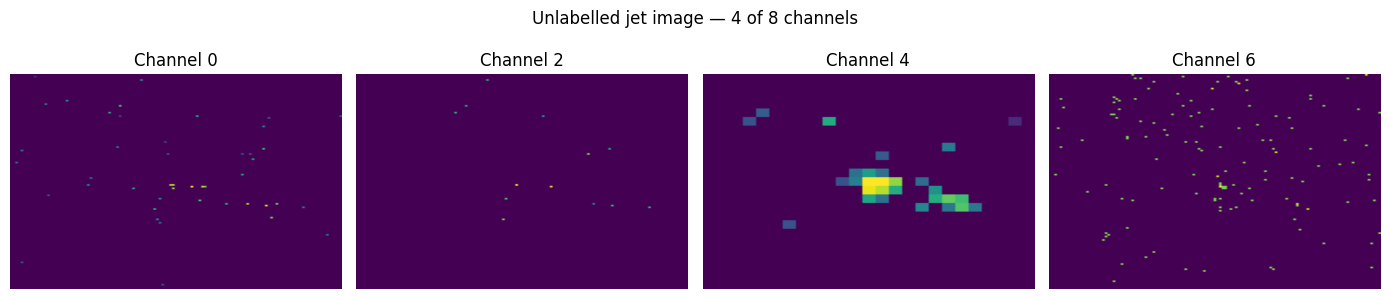

In [4]:
class UnlabelledJetDataset(Dataset):
    """
    Streams 8-channel jet images directly from the HDF5 file.
    Applies log1p + per-sample max-norm (same as regression_dataset.py).
    No labels — returns image tensor only.
    """
    def __init__(self, h5_path: str):
        self.h5_path = h5_path
        with h5py.File(h5_path, "r") as f:
            self.N = f["jet"][:30000].shape[0]
        print(f"Dataset: {self.N} unlabelled jet images at {h5_path}")

    def __len__(self): return self.N

    def __getitem__(self, idx):
        with h5py.File(self.h5_path, "r") as f:
            x = f["jet"][idx].astype(np.float32)   # (125, 125, 8)
        x = np.log1p(x)
        x = x / (x.max() + 1e-8)                   # per-sample max-norm → [0,1]
        return torch.from_numpy(x).permute(2, 0, 1) # (8, 125, 125)


dataset    = UnlabelledJetDataset(H5_PATH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True)
print(f"Batches per epoch : {len(dataloader)}")

# Quick sanity check — visualise channel 0 of the first sample
sample = dataset[0]
print(f"Sample shape: {sample.shape}  min={sample.min():.3f}  max={sample.max():.3f}")
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for c, ax in zip([0, 2, 4, 6], axes):
    ax.imshow(sample[c].numpy(), cmap="viridis", aspect="auto")
    ax.set_title(f"Channel {c}"); ax.axis("off")
plt.suptitle("Unlabelled jet image — 4 of 8 channels", fontsize=12)
plt.tight_layout(); plt.show()


## 5 · XCiT Encoder Building Blocks
These classes are **identical** to those in `xcit-multitask.ipynb`. They must not be
modified — Phase 2 uses `load_state_dict` to transfer weights.

### Cross-Covariance Attention (XCA)
$$\mathcal{A}_{XC}(K,Q) = \mathrm{Softmax}\!\left(\hat{K}^\top\hat{Q}/\tau\right)$$

Attention map is `(d/h × d/h)` instead of `(N × N)` → **O(N)** complexity in token count.

In [5]:
class DropPath(nn.Module):
    """Stochastic depth (Huang et al., ECCV 2016)."""
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p == 0.0: return x
        keep = 1 - self.p
        mask = (torch.rand((x.shape[0],) + (1,) * (x.ndim - 1),
                           device=x.device) < keep).float()
        return x * mask / keep


class XCA(nn.Module):
    """Cross-Covariance Attention — O(N·d²/h) in token count."""
    def __init__(self, dim, num_heads=8, qkv_bias=False, dropout=0.0):
        super().__init__()
        self.num_heads   = num_heads
        self.head_dim    = dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv  = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Sequential(nn.Linear(dim, dim), nn.Dropout(dropout))

    def forward(self, x):
        B, N, C = x.shape
        h = self.num_heads
        qkv = self.qkv(x).reshape(B, N, 3, h, C // h)
        qkv = qkv.permute(2, 0, 3, 1, 4).contiguous()     # (3, B, h, N, d/h)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q.transpose(-2, -1).contiguous()               # (B, h, d/h, N)
        k = k.transpose(-2, -1).contiguous()
        v = v.transpose(-2, -1).contiguous()

        q = F.normalize(q, dim=-1, p=2)
        k = F.normalize(k, dim=-1, p=2)

        attn = (k @ q.transpose(-2, -1).contiguous()) * self.temperature
        attn = attn.softmax(dim=-1)
        out  = attn @ v
        out  = out.permute(0, 3, 1, 2).contiguous().reshape(B, N, C)
        return self.proj(out)


class LPI(nn.Module):
    """Local Patch Interaction — two depth-wise 3×3 convs (Section 3.3)."""
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size, padding=pad, groups=dim, bias=False),
            nn.GELU(),
            nn.BatchNorm2d(dim),
            nn.Conv2d(dim, dim, kernel_size, padding=pad, groups=dim, bias=False),
        )
    def forward(self, x, H, W):
        B, N, C = x.shape
        x2 = x.transpose(1, 2).contiguous().view(B, C, H, W)
        return self.net(x2).flatten(2).transpose(1, 2).contiguous()


class XCiTBlock(nn.Module):
    """XCiT encoder block: XCA → LPI → FFN, each with residual + LayerNorm."""
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.norm1     = nn.LayerNorm(dim)
        self.norm2     = nn.LayerNorm(dim)
        self.norm3     = nn.LayerNorm(dim)
        self.xca       = XCA(dim, num_heads=num_heads, dropout=dropout)
        self.lpi       = LPI(dim)
        self.ffn       = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * mlp_ratio, dim), nn.Dropout(dropout),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, x, H, W):
        x = x + self.drop_path(self.xca(self.norm1(x)))
        x = x + self.drop_path(self.lpi(self.norm2(x), H, W))
        x = x + self.drop_path(self.ffn(self.norm3(x)))
        return x


class ClassAttention(nn.Module):
    """One-way class attention (CaiT-style): only the CLS token is updated."""
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5
        self.q         = nn.Linear(dim, dim)
        self.kv        = nn.Linear(dim, dim * 2)
        self.proj      = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        h = self.num_heads
        q  = self.q(x[:, :1]).reshape(B, 1, h, C // h).permute(0, 2, 1, 3).contiguous()
        kv = self.kv(x).reshape(B, N, 2, h, C // h).permute(2, 0, 3, 1, 4).contiguous()
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1).contiguous()) * self.scale
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1, 2).contiguous().reshape(B, 1, C)
        return torch.cat([self.proj(out), x[:, 1:]], dim=1)


class ClassAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.attn  = ClassAttention(dim, num_heads)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))
    def forward(self, x):
        x     = x + self.attn(self.norm1(x))
        x_cls = x[:, :1] + self.ffn(self.norm2(x[:, :1]))
        return torch.cat([x_cls, x[:, 1:]], dim=1)


class SinCos2DPosEmb(nn.Module):
    """Sinusoidal 2D positional encoding (Appendix B.1)."""
    def __init__(self, dim, temperature=10000):
        super().__init__()
        assert dim % 4 == 0
        self.temperature = temperature
        self.proj = nn.Linear(64, dim)

    def forward(self, H, W, device):
        y_pos = torch.arange(H, device=device).unsqueeze(1).float()
        x_pos = torch.arange(W, device=device).unsqueeze(1).float()
        freqs = torch.arange(16, device=device).float()
        omega = 1.0 / (self.temperature ** (freqs / 16))
        y_enc = torch.cat([torch.sin(y_pos * omega), torch.cos(y_pos * omega)], dim=-1)
        x_enc = torch.cat([torch.sin(x_pos * omega), torch.cos(x_pos * omega)], dim=-1)
        grid_y = y_enc.unsqueeze(1).expand(H, W, 32)
        grid_x = x_enc.unsqueeze(0).expand(H, W, 32)
        pos = torch.cat([grid_y, grid_x], dim=-1).reshape(H * W, 64)
        return self.proj(pos)

print("XCiT building blocks defined.")


XCiT building blocks defined.


## 6 · XCiT Encoder
The encoder is the full XCiT backbone **without any classification head**.
It includes `cls_token` and `cls_blocks` purely for weight-compatibility with Phase 2
(where `head_cls` sits on top of the CLS token output). During MAE pretraining the CLS
path is not used — only patch tokens are fed to the decoder.

In [6]:
class XCiTEncoder(nn.Module):
    """
    XCiT encoder for MAE pretraining.
    Keeps full patch grid by using mask tokens for masked positions.
    """
    def __init__(self,
                 image_size  = IMAGE_SIZE,
                 patch_size  = PATCH_SIZE,
                 in_channels = IN_CHANNELS,
                 dim         = DIM,
                 depth       = DEPTH,
                 num_heads   = NUM_HEADS,
                 mlp_ratio   = MLP_RATIO,
                 cls_depth   = CLS_DEPTH,
                 dropout     = DROPOUT,
                 drop_path   = DROP_PATH):
        super().__init__()
        self.patch_size = patch_size
        self.H = self.W = image_size // patch_size   # 25

        # Patch embedding
        self.patch_embed = nn.Conv2d(in_channels, dim,
                                     kernel_size=patch_size, stride=patch_size)
        self.emb_norm    = nn.LayerNorm(dim)
        self.pos_emb     = SinCos2DPosEmb(dim)

        # Learnable mask token — for masked patch positions
        self.mask_token  = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        # XCiT encoder blocks
        dpr = [x.item() for x in torch.linspace(0, drop_path, depth)]
        self.blocks = nn.ModuleList([
            XCiTBlock(dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)

        # CLS token + class-attention (weight-compatibility with Phase 2 only)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.cls_blocks = nn.ModuleList([
            ClassAttentionBlock(dim, num_heads) for _ in range(cls_depth)
        ])
        self.cls_norm = nn.LayerNorm(dim)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, visible_mask):
        """
        Args:
            x            : (B, C, H_img, W_img) — full image
            visible_mask : (B, N) bool — True for visible (unmasked) patches

        Returns:
            visible_tokens : (B, N_vis, dim) — only visible patch tokens
            pos_full       : (N, dim)  — full positional encoding
            H, W           : patch grid dimensions (25, 25)
        """
        B  = x.shape[0]
        H, W = self.H, self.W
        N = H * W  # 625 total patches

        # 1. Patch embed → (B, N, dim)
        x_emb = self.patch_embed(x)                           # (B, dim, H, W)
        x_emb = x_emb.flatten(2).transpose(1, 2).contiguous() # (B, N, dim)

        # 2. Full positional encoding
        pos_full = self.pos_emb(H, W, x.device)               # (N, dim)

        # 3. Add pos encoding and norm to ALL patches
        x_emb = self.emb_norm(x_emb + pos_full.unsqueeze(0))  # (B, N, dim)

        # 4. Build FULL sequence: replace masked patches with mask tokens
        x_full = x_emb.clone()
        x_full[~visible_mask] = self.mask_token.expand(B, N, -1)[~visible_mask]
        # Now x_full is (B, 625, dim) with mask tokens at masked positions

        # 5. Run XCiT blocks on FULL token sequence
        for blk in self.blocks:
            x_full = blk(x_full, H, W)  # ✅ LPI now has full (B, C, 25, 25) grid
        x_full = self.norm(x_full)

        # 6. Extract only visible tokens for decoder
        N_vis = visible_mask[0].sum().item()
        visible_tokens = x_full[visible_mask].reshape(B, N_vis, -1)  # (B, N_vis, dim)

        return visible_tokens, pos_full, H, W

## 7 · MAE Decoder
A lightweight standard (non-XCiT) transformer decoder. It receives:
- Encoded visible tokens (projected from encoder dim → decoder dim)
- Learnable mask tokens for every masked position
- Full positional encoding for all positions

It predicts the raw patch pixel values for **all** positions, and the loss is computed
only on the **masked** positions. The decoder is **discarded** after pretraining.

In [7]:
class MAEDecoder(nn.Module):
    """
    Lightweight transformer decoder for MAE.
    Input  : visible encoded tokens + mask tokens, all with positional encoding
    Output : reconstructed patch pixel values for all N patches
    Loss   : MSE on masked patch positions only
    """
    def __init__(self,
                 encoder_dim  = DIM,
                 decoder_dim  = DECODER_DIM,
                 decoder_depth= DECODER_DEPTH,
                 decoder_heads= DECODER_HEADS,
                 patch_size   = PATCH_SIZE,
                 in_channels  = IN_CHANNELS,
                 num_patches  = NUM_PATCHES):
        super().__init__()

        patch_pixels = in_channels * patch_size * patch_size   # 8 × 5 × 5 = 200

        # Project encoder dim → decoder dim
        self.enc_to_dec = nn.Linear(encoder_dim, decoder_dim, bias=True)

        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        # Positional encoding for decoder (learned, small)
        self.dec_pos_emb = nn.Embedding(num_patches, decoder_dim)

        # Decoder transformer blocks (standard MHSA — no XCA needed)
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=decoder_heads,
            dim_feedforward=decoder_dim * 4,
            dropout=0.0, activation="gelu",
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(decoder_layer,
                                                  num_layers=decoder_depth)
        self.norm = nn.LayerNorm(decoder_dim)

        # Final projection → patch pixels
        self.pred = nn.Linear(decoder_dim, patch_pixels)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, visible_tokens, visible_mask, num_patches):
        """
        Args:
            visible_tokens : (B, N_vis, encoder_dim)
            visible_mask   : (B, N) bool — True = visible
            num_patches    : N (total)

        Returns:
            pred : (B, N, patch_pixels) — predictions for ALL positions
        """
        B = visible_tokens.shape[0]
        device = visible_tokens.device

        # 1. Project visible tokens to decoder dim
        vis = self.enc_to_dec(visible_tokens)   # (B, N_vis, D_dec)

        # 2. Build full sequence: visible tokens + mask tokens at masked positions
        tokens = self.mask_token.expand(B, num_patches, -1).clone()  # (B, N, D_dec)
        tokens = tokens.to(vis.dtype)
        tokens[visible_mask] = vis.reshape(-1, vis.shape[-1])

        # 3. Add positional embeddings (all positions)
        pos_ids = torch.arange(num_patches, device=device).unsqueeze(0).expand(B, -1)
        tokens  = tokens + self.dec_pos_emb(pos_ids)

        # 4. Transformer
        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)

        # 5. Predict patch pixels
        return self.pred(tokens)   # (B, N, patch_pixels)


dec = MAEDecoder().to(DEVICE)
n_dec = sum(p.numel() for p in dec.parameters() if p.requires_grad)
print(f"Decoder parameters : {n_dec:,}")
del dec


/tmp/ipykernel_24/1400917212.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(decoder_layer,


Decoder parameters : 545,576


## 8 · Full MAE Model + Random Masking
The masking strategy follows MAE exactly:
1. Randomly shuffle patch indices per image
2. Keep the first `N × (1 - mask_ratio)` as visible
3. Pass only visible patches through the encoder (efficient — 75% fewer tokens)
4. Reconstruct all patches in the decoder

In [8]:
class XCiTMAE(nn.Module):
    """
    Masked Autoencoder with XCiT encoder.
    Three fixes for sparse jet images:
      1. Patch-normalised targets  — normalise each patch to zero mean/unit std
         before computing MSE, so the model must reconstruct relative structure
         within patches rather than predicting "all zeros" trivially.
      2. Activity-weighted loss    — patches containing signal are upweighted
         (weight=ACTIVE_PATCH_WEIGHT) vs background patches (weight=1.0).
         Prevents the model from ignoring rare but important energy deposits.
      3. Mask ratio 60%            — more visible patches means the encoder
         sees more signal tokens, critical when signal is sparse.
    encoder : XCiTEncoder  (kept for Phase 2)
    decoder : MAEDecoder   (discarded after pretraining)
    """
    # Weight applied to active (non-zero) patches in the reconstruction loss
    ACTIVE_PATCH_WEIGHT = 10.0

    def __init__(self, mask_ratio=MASK_RATIO):
        super().__init__()
        self.mask_ratio  = mask_ratio
        self.num_patches = NUM_PATCHES
        self.patch_size  = PATCH_SIZE
        self.in_channels = IN_CHANNELS
        self.encoder     = XCiTEncoder()
        self.decoder     = MAEDecoder()

    def random_mask(self, B, N, device):
        """Random masking. Returns visible_mask and masked_mask, both (B, N) bool."""
        N_vis  = int(N * (1 - self.mask_ratio))
        noise  = torch.rand(B, N, device=device)
        ids    = noise.argsort(dim=1)
        visible_mask = torch.zeros(B, N, dtype=torch.bool, device=device)
        visible_mask.scatter_(1, ids[:, :N_vis], True)
        return visible_mask, ~visible_mask

    def patchify(self, imgs):
        """(B, C, H, W) → (B, N, C*ps*ps) — raw patch pixel values."""
        ps = self.patch_size
        B, C, H, W = imgs.shape
        H_p, W_p = H // ps, W // ps
        x = imgs.reshape(B, C, H_p, ps, W_p, ps)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()   # (B, H_p, W_p, C, ps, ps)
        return x.reshape(B, H_p * W_p, C * ps * ps)      # (B, N, C*ps*ps)

    def patch_normalise(self, patches):
        """
        Normalise each patch to zero mean, unit variance.
        Fix 1: prevents trivial zero-prediction on sparse images.
        (B, N, D) → (B, N, D) normalised, also returns mean and std for denorm.
        """
        mean = patches.mean(dim=-1, keepdim=True)          # (B, N, 1)
        std  = patches.std(dim=-1, keepdim=True).clamp(min=1e-6)  # (B, N, 1)
        return (patches - mean) / std, mean, std

    def activity_weights(self, patches):
        """
        Fix 2: compute per-patch loss weights.
        A patch is 'active' if its mean absolute value exceeds a small threshold.
        Active patches get weight ACTIVE_PATCH_WEIGHT, background patches weight 1.
        (B, N, D) → (B, N) float weights
        """
        activity = patches.abs().mean(dim=-1)              # (B, N)
        threshold = activity.mean() * 0.1                  # 10% of mean activity
        weights = torch.where(activity > threshold,
                              torch.full_like(activity, self.ACTIVE_PATCH_WEIGHT),
                              torch.ones_like(activity))
        return weights

    def forward(self, imgs):
        """
        Returns:
            loss         : scalar — activity-weighted MSE on patch-normalised targets
            pred         : (B, N, C*ps*ps) — predicted patches (normalised space)
            masked_mask  : (B, N) bool — which patches were masked
        """
        B, C, H, W = imgs.shape
        N = self.num_patches
        visible_mask, masked_mask = self.random_mask(B, N, imgs.device)

        # Encode visible patches only
        vis_tokens, pos_full, Hg, Wg = self.encoder(imgs, visible_mask)

        # Decode → predict all N positions
        pred = self.decoder(vis_tokens, visible_mask, N)    # (B, N, C*ps*ps)

        # Ground truth patches
        target_raw = self.patchify(imgs)                    # (B, N, C*ps*ps)

        # Fix 1 — normalise targets per patch
        target_norm, _, _ = self.patch_normalise(target_raw)

        # Fix 2 — activity-based loss weights (computed on raw targets)
        weights = self.activity_weights(target_raw)         # (B, N)

        # MSE on normalised targets, masked positions only
        loss_per_patch = ((pred - target_norm) ** 2).mean(dim=-1)  # (B, N)

        # Apply activity weights to masked patches
        masked_weights = weights[masked_mask]               # (N_masked_total,)
        masked_losses  = loss_per_patch[masked_mask]        # (N_masked_total,)
        loss = (masked_losses * masked_weights).sum() / masked_weights.sum()

        return loss, pred, masked_mask


# Sanity check
mae = XCiTMAE().to(DEVICE)
dummy = torch.randn(2, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
loss, pred, mask = mae(dummy)
print(f"MAE forward pass OK")
print(f"  loss  : {loss.item():.4f}")
print(f"  pred  : {pred.shape}")
print(f"  mask  : {mask.shape}  masked={mask[0].sum().item()}/{NUM_PATCHES}")
n_total = sum(p.numel() for p in mae.parameters() if p.requires_grad)
n_enc   = sum(p.numel() for p in mae.encoder.parameters() if p.requires_grad)
n_dec   = sum(p.numel() for p in mae.decoder.parameters() if p.requires_grad)
print(f"\nTotal params : {n_total:,}  |  Encoder : {n_enc:,}  |  Decoder : {n_dec:,}")
del dummy, loss, pred, mask


/tmp/ipykernel_24/1400917212.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(decoder_layer,


MAE forward pass OK
  loss  : 1.0328
  pred  : torch.Size([2, 625, 200])
  mask  : torch.Size([2, 625])  masked=375/625

Total params : 5,076,072  |  Encoder : 4,530,496  |  Decoder : 545,576


## 9 · Optimiser & LR Schedule

In [9]:
def build_mae_opt(model):
    # No weight decay on bias / norm / temperature parameters
    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias",
                "norm.weight", "norm.bias", "temperature"}
    decay_params   = [p for n, p in model.named_parameters()
                      if p.requires_grad and not any(nd in n for nd in no_decay)]
    nodecay_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and     any(nd in n for nd in no_decay)]

    opt = optim.AdamW([
        {"params": decay_params,   "weight_decay": WEIGHT_DECAY},
        {"params": nodecay_params, "weight_decay": 0.0},
    ], lr=LR, betas=(0.9, 0.95))   # MAE paper uses β₂=0.95

    # Cosine decay with linear warmup
    def lr_lambda(ep):
        if ep < WARMUP_EPOCHS:
            return (ep + 1) / WARMUP_EPOCHS
        t = (ep - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (1 + math.cos(math.pi * t))

    sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    return opt, sched


## 10 · Training Loop

In [10]:
def train_epoch_mae(model, loader, opt, scaler):
    model.train()
    total_loss, n = 0.0, 0
    n_batches = len(loader)

    for i, imgs in enumerate(loader):
        imgs = imgs.to(DEVICE)
        opt.zero_grad()
        with torch.amp.autocast(DEVICE.type, enabled=(DEVICE.type == "cuda")):
            loss, _, _ = model(imgs)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()

        bs = imgs.shape[0]
        total_loss += loss.item() * bs
        n          += bs

        pct    = (i + 1) / n_batches
        filled = int(30 * pct)
        bar    = "█" * filled + "░" * (30 - filled)
        print(f"\r  [{bar}] {i+1}/{n_batches}  loss={total_loss/n:.5f}",
              end="", flush=True)

    print()
    return total_loss / n


mae_model = XCiTMAE().to(DEVICE)
optimizer, scheduler = build_mae_opt(mae_model)
scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"Starting MAE pretraining for {EPOCHS} epochs")
print(f"Mask ratio: {MASK_RATIO:.0%}  |  Warmup: {WARMUP_EPOCHS} epochs")
print(f"{'Ep':>5} {'Loss':>10} {'LR':>10}  Time")
print("─" * 45)


/tmp/ipykernel_24/1400917212.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(decoder_layer,


Starting MAE pretraining for 43 epochs
Mask ratio: 60%  |  Warmup: 5 epochs
   Ep       Loss         LR  Time
─────────────────────────────────────────────


## 11 · Run Pretraining

In [11]:
history_loss = []
best_loss, best_ep = float("inf"), 0

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    loss = train_epoch_mae(mae_model, dataloader, optimizer, scaler)
    scheduler.step()
    history_loss.append(loss)

    lr_now = optimizer.param_groups[0]["lr"]
    flag   = " ◀ best" if loss < best_loss else ""
    print(f"{ep:>5}  {loss:>10.6f}  {lr_now:>10.2e}  {time.time()-t0:.1f}s{flag}")

    if loss < best_loss:
        best_loss, best_ep = loss, ep
        # Save ENCODER ONLY — this is what Phase 2 loads
        torch.save(mae_model.encoder.state_dict(), "best_xcit_mae.pth")
        # Also save full MAE checkpoint (resume training if needed)
        torch.save({
            "epoch": ep,
            "model": mae_model.state_dict(),
            "opt":   optimizer.state_dict(),
            "loss":  best_loss,
        }, "mae_checkpoint.pth")

print(f"\nBest loss {best_loss:.6f} at epoch {best_ep}")
print("Encoder weights saved → best_xcit_mae.pth  (load in Phase 2)")


  [██████████████████████████████] 938/938  loss=0.89839
    1    0.898387    2.00e-04  411.8s ◀ best
  [██████████████████████████████] 938/938  loss=0.88429
    2    0.884291    3.00e-04  395.5s ◀ best
  [██████████████████████████████] 938/938  loss=0.88300
    3    0.882997    4.00e-04  395.1s ◀ best
  [██████████████████████████████] 938/938  loss=0.88232
    4    0.882320    5.00e-04  398.6s ◀ best
  [██████████████████████████████] 938/938  loss=0.88169
    5    0.881695    5.00e-04  412.7s ◀ best
  [██████████████████████████████] 938/938  loss=0.88131
    6    0.881313    4.99e-04  417.2s ◀ best
  [██████████████████████████████] 938/938  loss=0.88099
    7    0.880994    4.97e-04  406.1s ◀ best
  [██████████████████████████████] 938/938  loss=0.88074
    8    0.880741    4.92e-04  404.6s ◀ best
  [██████████████████████████████] 938/938  loss=0.88050
    9    0.880500    4.86e-04  412.0s ◀ best
  [██████████████████████████████] 938/938  loss=0.88034
   10    0.880339    4.79

## 12 · Pretraining Loss Curve

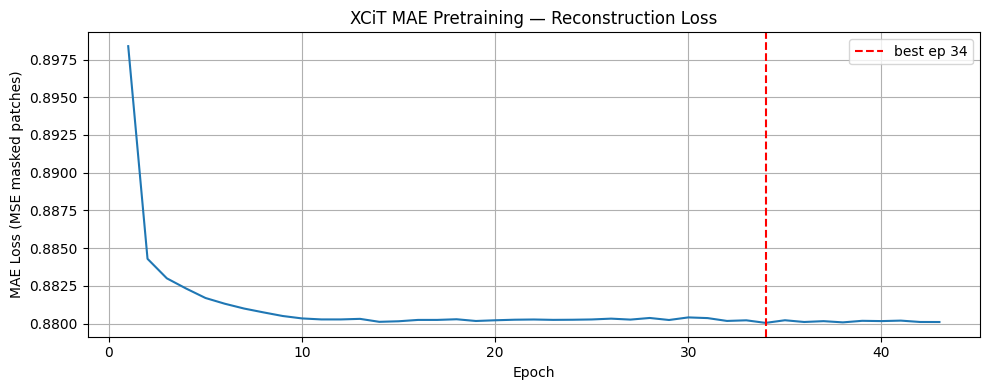

Saved xcit_mae_loss.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(history_loss)+1), history_loss, linewidth=1.5)
ax.axvline(best_ep, color="red", linestyle="--", label=f"best ep {best_ep}")
ax.set_xlabel("Epoch"); ax.set_ylabel("MAE Loss (MSE masked patches)")
ax.set_title("XCiT MAE Pretraining — Reconstruction Loss")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig("xcit_mae_loss.png", dpi=150); plt.show()
print("Saved xcit_mae_loss.png")


## 13 · Reconstruction Visualisation
Visual sanity check: are the reconstructed patches plausible?
Columns: original | masked input | reconstruction (channel 0 shown).

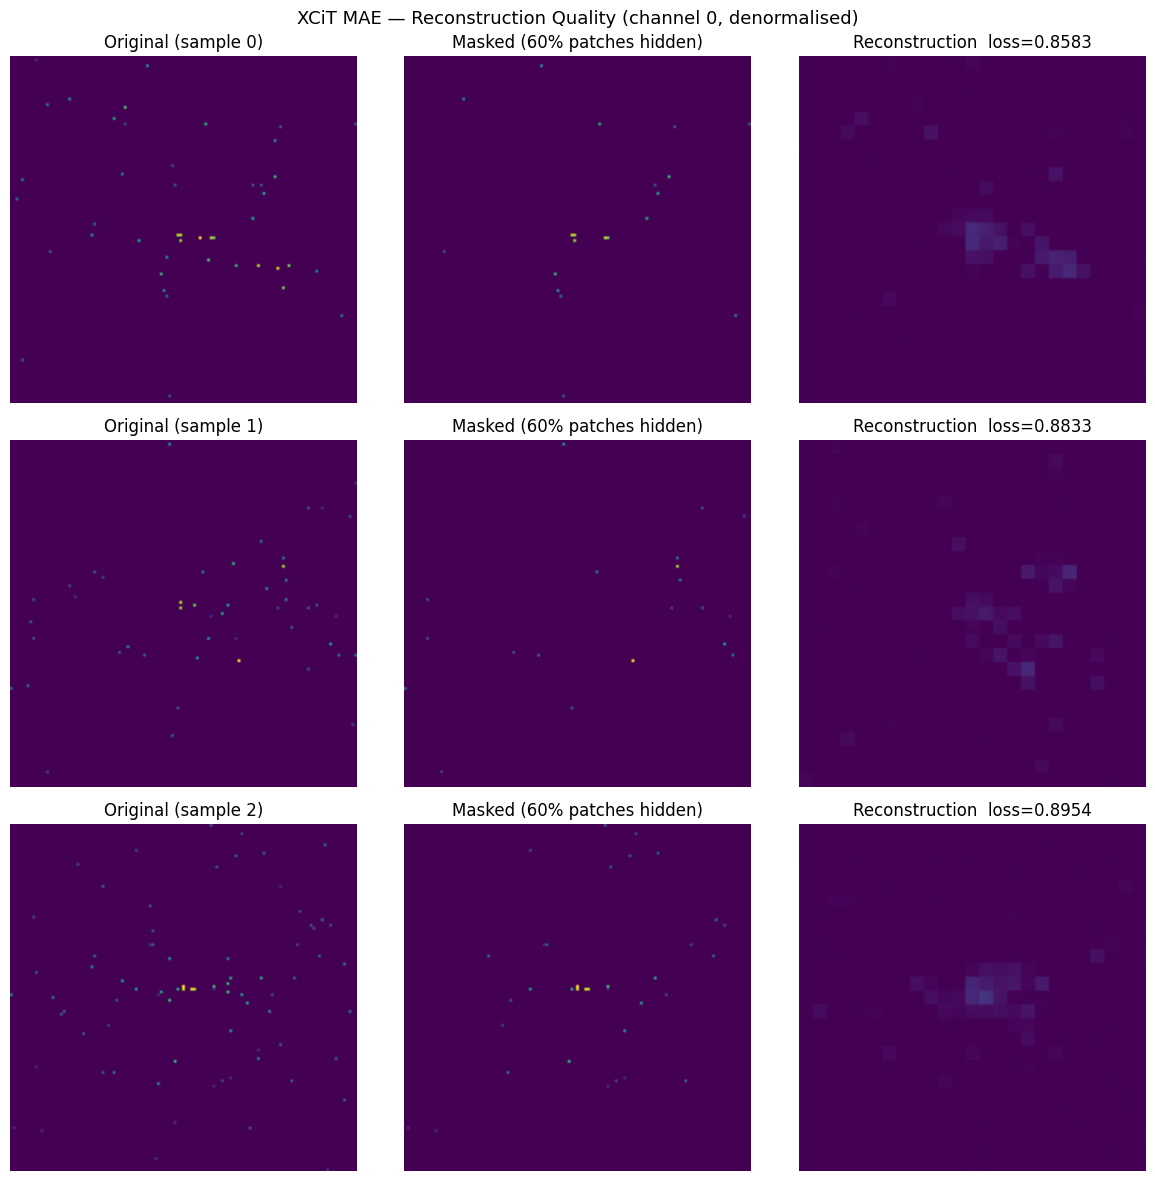

In [13]:
@torch.no_grad()
def visualise_reconstruction(model, dataset, n_samples=3):
    """
    Shows original | masked input | reconstruction.
    Reconstruction is in patch-normalised space, so we denormalise each patch
    back using the original patch mean/std for a fair visual comparison.
    """
    model.eval()
    ps   = model.patch_size
    H_p  = W_p = IMAGE_SIZE // ps   # 25

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    axes = axes.reshape(n_samples, 3)

    for row in range(n_samples):
        img = dataset[row].unsqueeze(0).to(DEVICE)          # (1, 8, 125, 125)
        loss, pred, masked = model(img)

        # Ground truth patches and their per-patch stats
        target_raw = model.patchify(img)                    # (1, N, C*ps*ps)
        _, p_mean, p_std = model.patch_normalise(target_raw)  # (1,N,1) each

        # Denormalise predictions: pred is in normalised space
        pred_denorm = pred * p_std + p_mean                 # (1, N, C*ps*ps)

        # Unpatchify prediction → full image
        B, N, _ = pred_denorm.shape
        rec = pred_denorm.reshape(B, H_p, W_p, IN_CHANNELS, ps, ps)
        rec = rec.permute(0, 3, 1, 4, 2, 5).contiguous()   # (B,C,H_p,ps,W_p,ps)
        rec = rec.reshape(B, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

        # Masked input visualisation — zero out masked patches
        masked_img = img.clone()
        mask_2d = masked[0].reshape(H_p, W_p)
        for hp in range(H_p):
            for wp in range(W_p):
                if mask_2d[hp, wp]:
                    masked_img[0, :, hp*ps:(hp+1)*ps, wp*ps:(wp+1)*ps] = 0.0

        orig_ch0 = img[0, 0].cpu().numpy()
        mask_ch0 = masked_img[0, 0].cpu().numpy()
        rec_ch0  = rec[0, 0].cpu().numpy().clip(0, 1)

        # Use the original's vmin/vmax so all three panels are on the same scale
        vmin, vmax = orig_ch0.min(), orig_ch0.max()

        axes[row, 0].imshow(orig_ch0, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"Original (sample {row})")
        axes[row, 1].imshow(mask_ch0, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"Masked ({model.mask_ratio:.0%} patches hidden)")
        axes[row, 2].imshow(rec_ch0,  cmap="viridis", vmin=vmin, vmax=vmax)
        axes[row, 2].set_title(f"Reconstruction  loss={loss.item():.4f}")
        for ax in axes[row]: ax.axis("off")

    plt.suptitle("XCiT MAE — Reconstruction Quality (channel 0, denormalised)",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig("xcit_mae_reconstruction.png", dpi=150); plt.show()


mae_model.load_state_dict(
    torch.load("mae_checkpoint.pth", map_location=DEVICE)["model"])
visualise_reconstruction(mae_model, dataset, n_samples=3)


## 14 · Files Produced for Phase 2

| File | Contents | Used by |
|---|---|---|
| `best_xcit_mae.pth` | Encoder `state_dict` (best reconstruction loss) | Phase 2 fine-tuning |
| `mae_checkpoint.pth` | Full MAE checkpoint (resume training) | Optional |
| `xcit_mae_loss.png` | Pretraining loss curve | Reporting |
| `xcit_mae_reconstruction.png` | Reconstruction visualisation | Reporting |

**In Phase 2 (`xcit-multitask.ipynb`):**
```python
enc_state = torch.load("best_xcit_mae.pth", map_location=DEVICE)
# Remap encoder keys → multitask model keys (they share the same namespace)
missing, unexpected = model_ft.load_state_dict(enc_state, strict=False)
# Only head_cls / head_mass / head_pt should appear in `missing` — expected.
```